# BMW dataset Analysis
#### We have our model already built and ready for testing on real data. We use the BMW vehicle specs dataset that includes prices of a certain BMW car, sales, car name, and etc. Goal is to test significance of the price as predictor for sales using simple linear regression.

# Data import 
#### We start by importing our data, nothing fancy but we must feed absolute paths so we can run from the project root.


In [1]:
%load_ext autoreload
%autoreload

from pathlib import Path
import csv

BASE_PATH = Path().resolve()
DATA_PATH = BASE_PATH / 'bmw_saless.csv'

sales, price = [],[]
try:
    with open(DATA_PATH, newline="") as csvfile:
        data = csv.DictReader(csvfile)
        for row in data:
            price.append(row['Price_USD'])
            sales.append(row['Sales_Volume'])
        print('import successful')
except Exception as e:
    print(f'not working: {e}')



import successful


 Data is represented as a 50,000 x 2 matrix to feed into `LineReg` class

In [2]:
import numpy as np 
data = np.column_stack(
    [np.array(price, dtype=np.float64), 
     np.array(sales, dtype = np.float64)] ) 
data.shape

(50000, 2)

# Plotting distribution
#### Lets look at the distribution of prices for each BMW. We will sample a random choice of 10,000 values and seperate them in $n$ bins

(np.float64(74734.7041), np.float64(25905.896307936215))

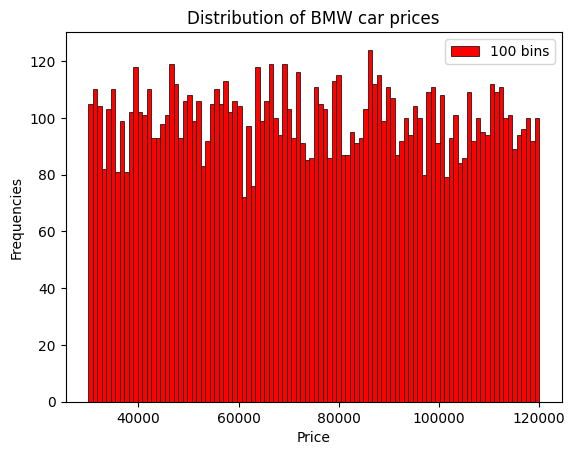

In [3]:
import matplotlib.pyplot as plt

np.random.seed(32131)

samp = np.random.choice(data[:,0], size=10000)
fig, ax1 = plt.subplots()
n_bins = 100
ax1.hist(samp, bins=n_bins, label=f'{n_bins} bins', color='red', linewidth=0.5,edgecolor='black')
ax1.set_ylabel('Frequencies')
ax1.set_xlabel('Price')
ax1.set_title('Distribution of BMW car prices')
ax1.legend()

np.mean(samp), np.std(samp)

# Plotting BMW car sales against price
#### A great way to diagnose the data even before testing, we can catch some early indications of a relationship of the two variables.

Text(0.5, 1.0, 'BMW car Sales plotted against  Price')

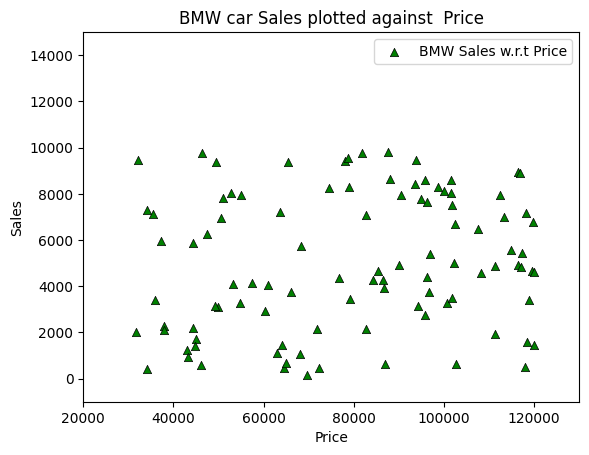

In [4]:
fig, ax2 = plt.subplots()
ax2.scatter(data[:,0][:100], data[:,1][:100], label='BMW Sales w.r.t Price', color='green', marker='^',
           edgecolor='black',linewidth=0.5)

ax2.legend()
ax2.set_ylabel('Sales')
ax2.set_xlabel('Price')
ax2.set_ylim(-1000,15000)
ax2.set_xlim(20000,130000)
ax2.set_title('BMW car Sales plotted against  Price')

## Some comments on the plot
#### A weak or almost no relationship can be observed, data is randomly scattered. This is an informal way of declaring no relationship between the two variables lets do some testing and some more plots to get an accurate view of our data. 


#### We can do some testing with our `LineReg()` class from our user created module `linereg.py`

In [5]:
import sys
MOD_PATH = str(Path().resolve().parent)
sys.path.append(MOD_PATH)
try:
    from reg_model.linereg import LineReg
    print('import successful')
except Exception as e:
    print(f'not working {e} \n syspath \n {sys.path}')


import successful


#### By convention from other packages and modules, we have a `.fit()` method to run the calculations using numpy (which uses C or Fortran code for all matrix operations, giving us that compiled language speed) of all our estimates using the data 
#### logic of the calculations can be seen from the source code.

In [6]:
model = LineReg(data)
model.fit()

#### Use `get_params()` method to find the linear estimators $b_1$ and $b_0$. Where $b_1$ is slope and $b_0$ is our intercept for our fitted model $\hat{Y} = b_0 + b_1X_i$.

In [8]:
params = model.get_params()
print(params)

{
    "intercept": "5066.8586783761",
    "slope (price)": "0.0000087427"
}


#### Our fitted model $\hat{Y} = 5066.8586783761 + 0.0000087427X_i$.

#### We also have the "revolutionary and never seen before `.summary()` method.
#### Okay so maybe its not so revolutionary apparently its in the other language called R or something. 
#### All jokes aside, we can grab our the value, error, and $t$-value of our linear estimates.

In [10]:
summary = model.summary()
print(summary)

{
    "Estimate": {
        "intercept": "5066.8586784",
        "slope (b_1)": "0.0000087"
    },
    "Std. Error": {
        "intercept": "39.0242348",
        "slope (b_1)": "0.0004914"
    },
    "t-value": {
        "intercept": "129.8387709",
        "slope (b_1)": "0.0177905"
    }
}


#### Lastly, we have our ANOVA (analysis of variance) table.

In [12]:
table = model.anova()
print(table)

{
    "Regression": {
        "SSR": 2583.0700704050305,
        "df": 1,
        "MSR": 2583.0700704050305
    },
    "Error": {
        "SSE": 408047756688.1548,
        "df": 49998,
        "MSE": 8161281.585026497
    },
    "Total": {
        "SSTo": 408047759271.22485,
        "df total": 49999
    },
    "F-stat": 0.00031650299569913005
}


#### Now that we have exhausted our methods for our `LineReg` class we can address the model which, to be frank, is pretty worthless at the moment. Lets go deeper into why.
#### The scatter plot gave it away, but we can compute the $R^2$ statistic to see how much of the variabllity of $Y_i$ is attributed to $X_i$

In [21]:
r_sq = model.compute_rstat(r_sq=True) # we can also compute r if set to False
float(r_sq)

6.3e-09

#### $6.3e^{-9} \approx 0$ so almost none of variance of $Y_i$ is attributed to $X_i$

# Hypothesis testing 
#### A hypothesis test can be conducted for testing the significance of the slope, and since we have our $F$ statistic we can easily set up our test.
$$
H_0: \beta_1 = 0 \quad H_1: \beta \neq 0
$$
#### Reject if $F_{obs} > F_{(1-\alpha, \ n-2)}$ with $\alpha=0.05$

In [48]:
from scipy.stats import f
import json

alpha = 0.05

dict_table = json.loads(table)
df1, df2 = dict_table['Regression']['df'], dict_table['Error']['df']
# df1 = 1, df2 = 49998

f_obs = dict_table['F-stat']
f_CritVal = f.ppf(1-alpha, df1, df2)

result = f_obs > f_CritVal
result.item()

False

#### We fail to reject the null that $\beta_1=0$ or that $\beta_1$ significant for our model. Essentially price has no effect on the sales of BMW vehicles.
#### Maybe as a business person, we could have reason through this by understanding BMW's customer base may include those who don't regard price as a factor in purchasing a BMW, this may be true, but with data we can empircally prove this fact.
#### This could open up more testing of different variables, customer data, etc in order to understand what is driving sales. This notebook is longwinded enough and I like to program more then writing. I would add residual plots in order to further enhance the point of linearity (that is is simply not present), but I think it may come off as redundant due to our result from the hypothesis test.
#### Thanks